# Práctica Deep Learning — Predicción de Engagement en POIs (Artgonuts)



In [38]:

# CONFIGURACIÓN

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Para que PyTorch sea determinista
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Entorno iniciado")


Entorno iniciado


In [39]:

# CARGA DE DATOS

import os

# Ruta local del ZIP (subido a Colab)
zip_path = "/content/data_main.zip"

# Crear carpeta data/
os.makedirs("data", exist_ok=True)

# Descomprimir
if not os.path.exists("data/data_main"):
    !unzip -q $zip_path -d data/
    print("Dataset descomprimido correctamente.")
else:
    print("Dataset ya estaba descomprimido.")

print("Contenido de la carpeta data/:")
!ls data/



Dataset ya estaba descomprimido.
Contenido de la carpeta data/:
data_main  poi_dataset.csv


In [40]:

# CARGA DEL CSV

csv_path = "data/poi_dataset.csv"

df = pd.read_csv(csv_path)

print("Filas:", len(df))
print("Columnas:", df.columns.tolist())
df.head()



Filas: 1569
Columnas: ['id', 'name', 'shortDescription', 'categories', 'tier', 'locationLon', 'locationLat', 'tags', 'xps', 'Visits', 'Likes', 'Dislikes', 'Bookmarks', 'main_image_path']


,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
0,4b36a3ed-3b28-4bc7-b975-1d48b586db03,Galería Fran Reus,La Galería Fran Reus es un espacio dedicado a ...,"['Escultura', 'Pintura']",1,2.642262,39.572694,[],500,10009,422,3582,78,data_main/4b36a3ed-3b28-4bc7-b975-1d48b586db03...
1,e32b3603-a94f-49df-8b31-92445a86377c,Convento de San Plácido,"El Convento de San Plácido en Madrid, fundado ...","['Patrimonio', 'Historia']",1,-3.704467,40.423037,[],500,10010,7743,96,2786,data_main/e32b3603-a94f-49df-8b31-92445a86377c...
2,0123a69b-13ac-4b65-a5d5-71a95560cff5,Instituto Geológico y Minero de España,"El Instituto Geológico y Minero de España, sit...","['Ciencia', 'Patrimonio']",2,-3.699694,40.442045,[],250,10015,3154,874,595,data_main/0123a69b-13ac-4b65-a5d5-71a95560cff5...
3,390d7d9e-e972-451c-b5e4-f494af15e788,Margarita Gil Roësset,"Margarita Gil Roësset, escultora y poetisa esp...",['Cultura'],1,-3.691228,40.427256,[],500,10011,8559,79,2358,data_main/390d7d9e-e972-451c-b5e4-f494af15e788...
4,023fc1bf-a1cd-4b9f-af78-48792ab1a294,Museo del Traje. Centro de Investigación del P...,"El Museo del Traje de Madrid, fundado en 2004,...","['Patrimonio', 'Cultura']",1,-3.727822,40.439665,[],500,10020,915,2896,143,data_main/023fc1bf-a1cd-4b9f-af78-48792ab1a294...


In [41]:
#CORRECCIÓN DE RUTAS Y COMPROBACIÓN DE IMÁGENES

import os

# Asegurar como empieza la ruta
df["main_image_path"] = df["main_image_path"].str.replace(r"^(data/)+", "", regex=True)
df["main_image_path"] = "data/" + df["main_image_path"]

# Cuántas imágenes existen realmente
df["image_exists"] = df["main_image_path"].apply(os.path.exists)

print("Total de imágenes:", len(df))
print("Imágenes encontradas:", df["image_exists"].sum())
print("Imágenes faltantes:", (~df["image_exists"]).sum())

df[~df["image_exists"]].head()


Total de imágenes: 1569
Imágenes encontradas: 1569
Imágenes faltantes: 0


,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path,image_exists


El dataset estructurado se cargó desde el archivo poi_dataset.csv, que contiene los metadatos asociados a cada punto de interés turístico (POI). En esta fase únicamente se verificó la lectura del archivo y nº de filas y columnas.

In [42]:

#CORRECCIÓN DE RUTAS DE IMÁGENES y MÉTRICA DE ENGAGEMENT
df["main_image_path"] = df["main_image_path"].str.replace(r"^(data/)+", "", regex=True)
df["main_image_path"] = "data/" + df["main_image_path"]

df["engagement_score"] = (
    0.4 * df["Visits"] +
    0.3 * df["Likes"] -
    0.2 * df["Dislikes"] +
    0.5 * df["Bookmarks"]
)


En el dataset no viene una columna que indique directamente si un POI tiene mucho o poco engagement, así que tuve que crear yo misma una métrica que lo represente. Para ello combiné varias señales de interacción que ya vienen en los datos: visitas, likes, dislikes y bookmarks.
Cada una de estas variables refleja un tipo distinto de interés del usuario, pero no todas tienen la misma importancia. Por eso les asigné pesos diferentes:

Bookmarks: los valoré más porque guardar un POI indica un interés fuerte.

Visits: también tienen bastante peso porque muestran que la gente realmente entra al contenido.

Likes: indican que el POI gusta, pero son menos fuertes que una visita o un bookmark.

Dislikes: restan engagement, aunque con un peso pequeño para que no afecten demasiado.

Con estos criterios construí una fórmula sencilla que combina todas estas señales en un único número llamado engagement_score. Esta puntuación me servirá después para convertir el problema en una clasificación (engagement alto o bajo) y poder entrenar el modelo.

In [43]:

#ETIQUETA BINARIA


#Umbral basado en el percentil 70
threshold = df["engagement_score"].quantile(0.70)

# Etiqueta binaria: 1 = engagement alto, 0 = engagement bajo
df["engagement_label"] = (df["engagement_score"] >= threshold).astype(int)

print("Creada")



Creada


In [15]:

# DIVISIÓN ESTRATIFICADA TRAIN / VAL / TEST

from sklearn.model_selection import train_test_split

# Extraemos id únicos y su etiqueta
poi_labels = df[["id", "engagement_label"]].drop_duplicates()

# 70% train, 30% temporal (val + test)
train_ids, temp_ids, y_train, y_temp = train_test_split(
    poi_labels["id"],
    poi_labels["engagement_label"],
    test_size=0.30,
    random_state=42,
    stratify=poi_labels["engagement_label"]
)

# 15% val, 15% test (50% del temporal)
val_ids, test_ids, y_val, y_test = train_test_split(
    temp_ids,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Reconstruimos los dataframes completos
df_train = df[df["id"].isin(train_ids)].copy()
df_val   = df[df["id"].isin(val_ids)].copy()
df_test  = df[df["id"].isin(test_ids)].copy()

print("Tamaños:")
print("Train:", len(df_train))
print("Val:", len(df_val))
print("Test:", len(df_test))

print("\nDistribución en train:")
print(df_train["engagement_label"].value_counts(normalize=True))

print("\nDistribución en val:")
print(df_val["engagement_label"].value_counts(normalize=True))

print("\nDistribución en test:")
print(df_test["engagement_label"].value_counts(normalize=True))


Tamaños:
Train: 1108
Val: 241
Test: 243

Distribución en train:
engagement_label
0    0.697653
1    0.302347
Name: proportion, dtype: float64

Distribución en val:
engagement_label
0    0.697095
1    0.302905
Name: proportion, dtype: float64

Distribución en test:
engagement_label
0    0.703704
1    0.296296
Name: proportion, dtype: float64


Para entrenar y evaluar el modelo de forma correcta, dividí el dataset en tres partes: entrenamiento, validación y prueba.
La  división es estratificada, es decir, que mantiene la misma proporción de clases (engagement alto y bajo) en cada subconjunto. Esto evita que el modelo aprenda con un conjunto desbalanceado y luego rinda mal en validación o test.

Primero hice un split entre train y un conjunto temporal. Después dividí ese conjunto temporal en validación y test, también de forma estratificada.
Finalmente reconstruí los dataframes completos usando los IDs de cada POI.


In [16]:
#NULOS EN TRAIN

df_train.isna().mean().sort_values(ascending=False)


,0
id,0.0
name,0.0
shortDescription,0.0
categories,0.0
tier,0.0
locationLon,0.0
locationLat,0.0
tags,0.0
xps,0.0
Visits,0.0


Después de dividir el dataset, analicé los valores nulos únicamente en el conjunto de entrenamiento para evitar cualquier fuga de información.
Calcular los nulos en el train me permite decidir qué columnas necesitan imputación o si alguna debería descartarse.
No hay nulos en train.

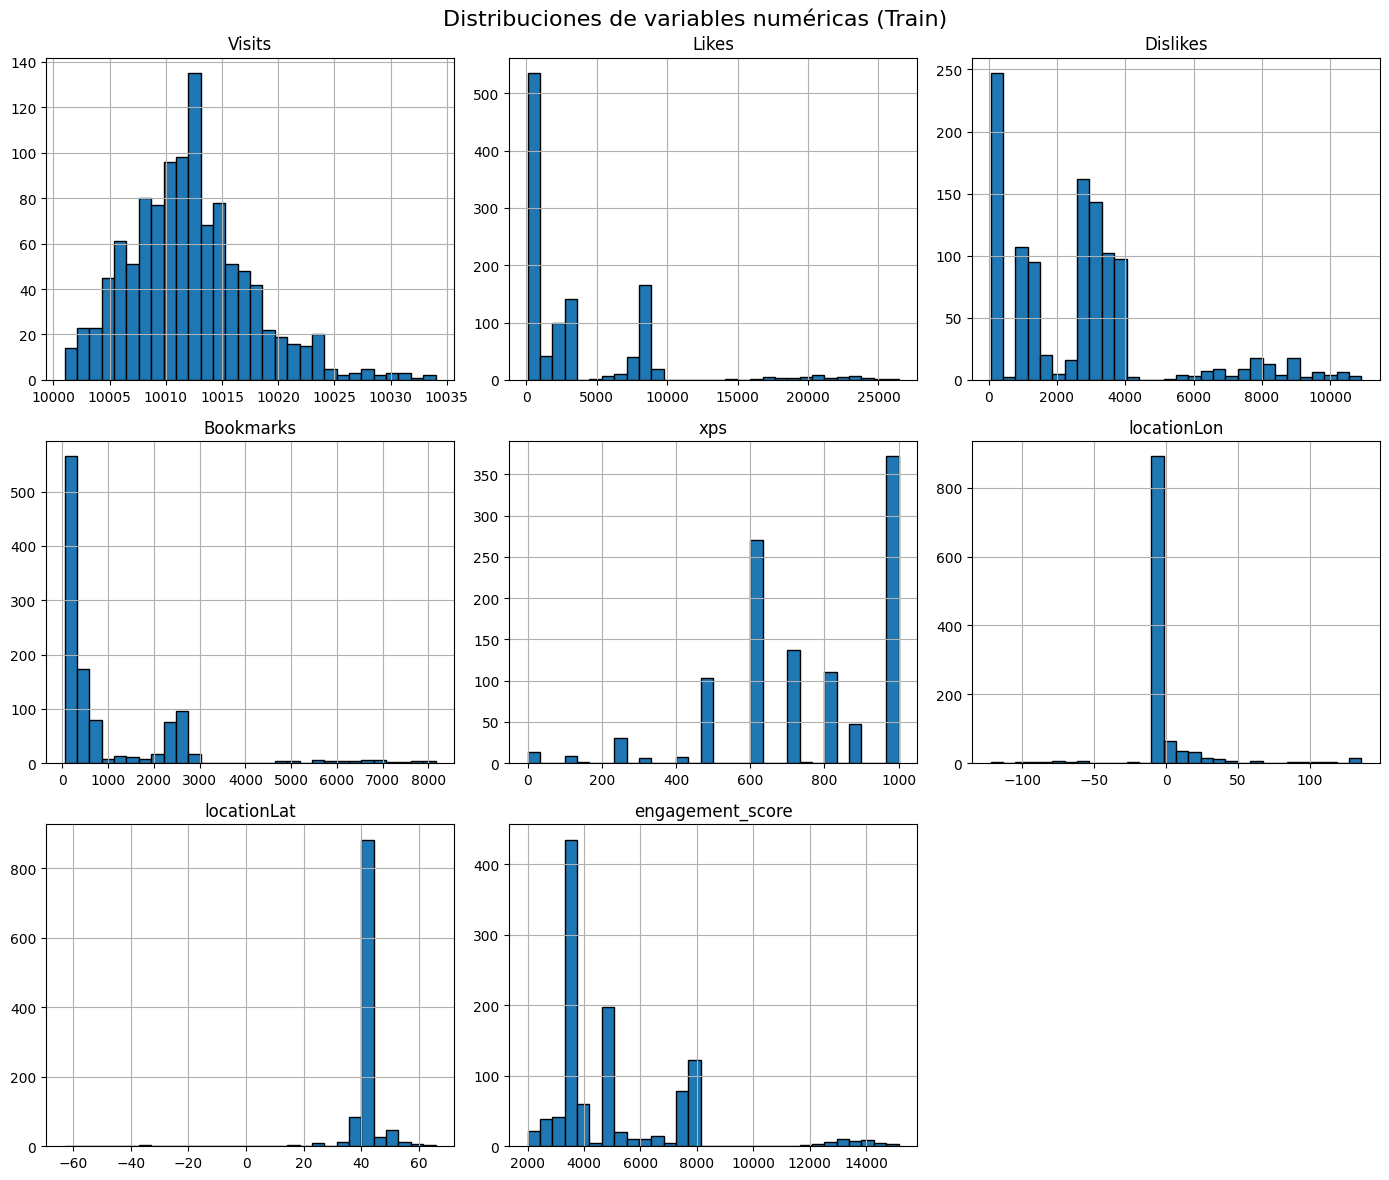

In [17]:

# DISTRIBUCIONES DE VARIABLES NUMÉRICAS

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["Visits", "Likes", "Dislikes", "Bookmarks", "xps",
                "locationLon", "locationLat", "engagement_score"]

df_train[numeric_cols].hist(figsize=(14, 12), bins=30, edgecolor='black')
plt.suptitle("Distribuciones de variables numéricas (Train)", fontsize=16)
plt.tight_layout()
plt.show()


Analicé las distribuciones de las variables numéricas del conjunto de entrenamiento para entender mejor cómo se comportan los datos. Las variables relacionadas con la interacción (Visits, Likes, Dislikes y Bookmarks) están muy concentradas en valores bajos, lo cual es normal porque la mayoría de POIs reciben poca actividad y solo unos pocos tienen valores muy altos.

Las coordenadas (locationLon y locationLat) también muestran una distribución concentrada, ya que todos los POIs pertenecen a la misma zona geográfica.
La variable xps presenta varios picos, lo que sugiere que puede tener valores discretos o niveles predefinidos.
Finalmente, la métrica de engagement que creé también muestra una distribución sesgada, heredando el comportamiento de las variables originales

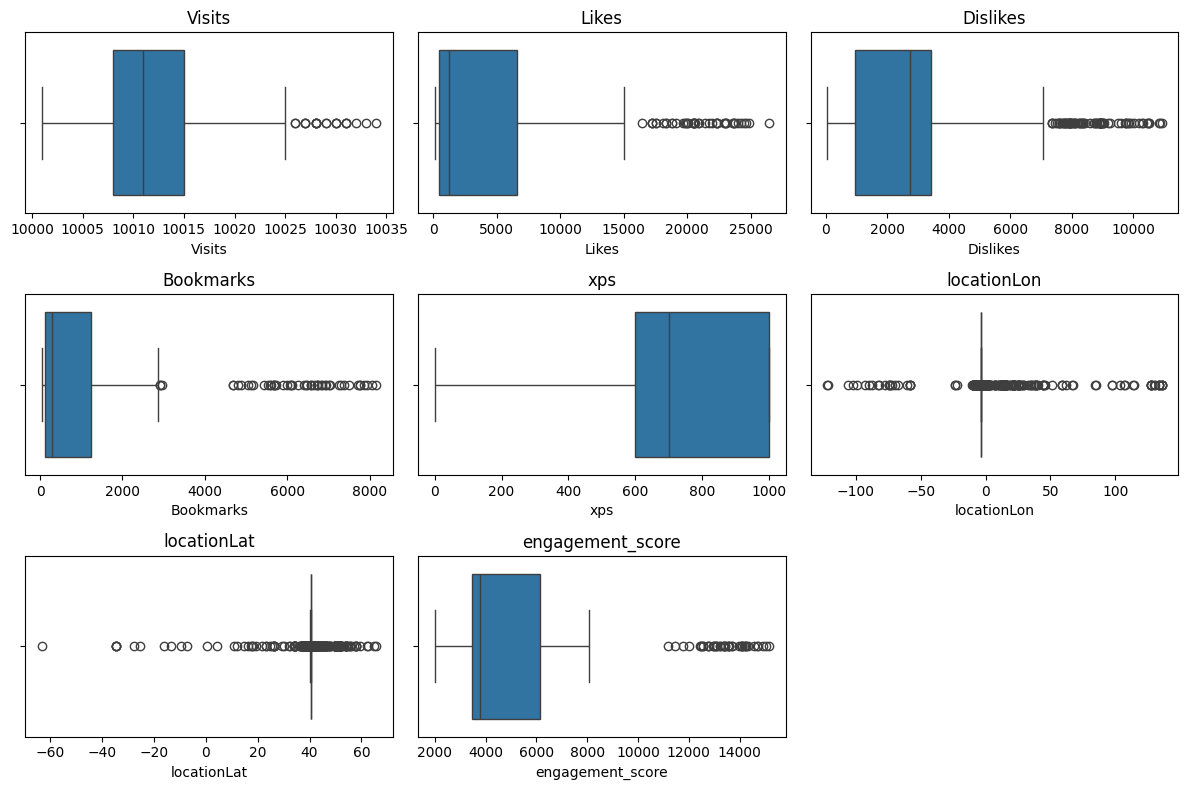

In [18]:
# DETECCIÓN DE OUTLIERS CON BOXPLOTS

plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()


Generé boxplots de todas las variables numéricas del conjunto de entrenamiento para identificar posibles valores extremos. Las variables relacionadas con la interacción (Visits, Likes, Dislikes y Bookmarks) muestran muchos outliers, lo cual es normal en este tipo de datos, ya que unos pocos POIs reciben mucha actividad mientras que la mayoría tienen valores bajos

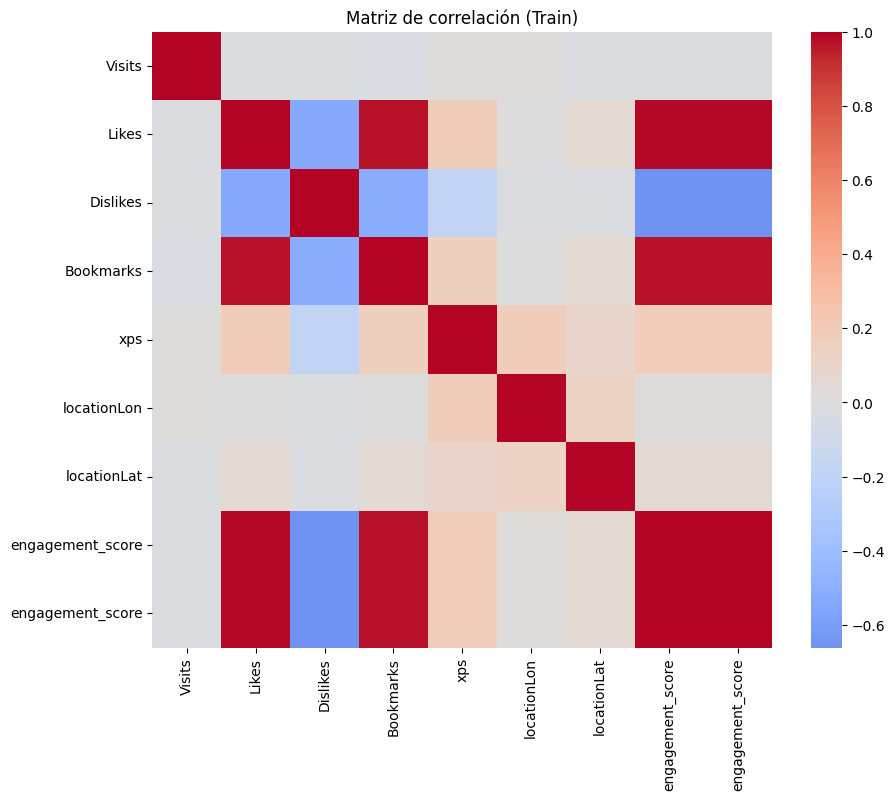

In [19]:

# MATRIZ DE CORRELACIÓN


import matplotlib.pyplot as plt
import seaborn as sns

corr = df_train[numeric_cols + ["engagement_score"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de correlación (Train)")
plt.show()


Para completar el análisis exploratorio, calculé la matriz de correlación utilizando únicamente el conjunto de entrenamiento. Las variables relacionadas con la interacción (Visits, Likes, Dislikes y Bookmarks) muestran correlaciones moderadas entre sí.
Las coordenadas geográficas apenas presentan correlación con el resto de variables, lo que indica que la ubicación no influye directamente en el engagement.

In [20]:
# PREPROCESADO PARA EMBEDDINGS

from collections import defaultdict

# Seleccionamos las variables categóricas
categorical_cols = ["categories", "tier"]

# Diccionarios para convertir categorías a índices
category_maps = {}

for col in categorical_cols:
    # Extraemos categorías únicas del TRAIN (muy importante)
    unique_vals = df_train[col].astype(str).unique()

    # Creamos el diccionario categoría → id
    cat2id = {cat: idx for idx, cat in enumerate(unique_vals, start=0)}

    # Añadimos un id especial para categorías desconocidas
    cat2id["__UNKNOWN__"] = len(cat2id)

    category_maps[col] = cat2id

# Función para mapear categorías a índices
def map_categories(df, col, mapping):
    return df[col].astype(str).apply(lambda x: mapping.get(x, mapping["__UNKNOWN__"]))

# Aplicamos la conversión en train/val/test
for col in categorical_cols:
    df_train[col + "_id"] = map_categories(df_train, col, category_maps[col])
    df_val[col + "_id"]   = map_categories(df_val, col, category_maps[col])
    df_test[col + "_id"]  = map_categories(df_test, col, category_maps[col])

# Calculamos tamaños de embedding para cada variable
embedding_sizes = {}

for col in categorical_cols:
    n_categories = len(category_maps[col])
    embedding_dim = min(50, round(1.6 * (n_categories ** 0.5)))
    embedding_sizes[col] = (n_categories, embedding_dim)

embedding_sizes


{'categories': (195, 22), 'tier': (5, 4)}

Extraigo las categorías únicas del conjunto de entrenamiento y creo un diccionario categoría→índice, añadiendo un token "unknown" para manejar categorías nuevas en validación o test. Después convierto las categorías de train/val/test a sus índices y calculo el tamaño de los embeddings en función del número de categorías

In [21]:
# ESCALADO DE VARIABLES NUMÉRICAS

from sklearn.preprocessing import StandardScaler

# Seleccionamos columnas numéricas
numeric_cols = ["Visits", "Likes", "Dislikes", "Bookmarks", "xps", "locationLon", "locationLat"]

# scaler
scaler = StandardScaler()

# Ajustamos train
scaler.fit(df_train[numeric_cols])

# Transformación train/val/test
df_train_scaled = df_train.copy()
df_val_scaled   = df_val.copy()
df_test_scaled  = df_test.copy()

df_train_scaled[numeric_cols] = scaler.transform(df_train[numeric_cols])
df_val_scaled[numeric_cols]   = scaler.transform(df_val[numeric_cols])
df_test_scaled[numeric_cols]  = scaler.transform(df_test[numeric_cols])

# Comprobación
df_train_scaled[numeric_cols].describe()


,Visits,Likes,Dislikes,Bookmarks,xps,locationLon,locationLat
count,1.108000e+03,1.108000e+03,1.108000e+03,1.108000e+03,1.108000e+03,1.108000e+03,1.108000e+03
mean,-1.020443e-13,-6.412841e-18,6.412841e-17,-3.847704e-17,2.052109e-16,-1.282568e-17,8.737495e-17
std,1.000452e+00,1.000452e+00,1.000452e+00,1.000452e+00,1.000452e+00,1.000452e+00,1.000452e+00
min,-2.047056e+00,-7.297540e-01,-1.108153e+00,-6.254917e-01,-3.240837e+00,-5.169365e+00,-1.234441e+01
25%,-7.521399e-01,-6.549210e-01,-7.214354e-01,-5.792480e-01,-6.345243e-01,-1.470660e-01,8.199807e-03
50%,-1.971759e-01,-4.872279e-01,6.586270e-02,-4.558747e-01,-2.001388e-01,-1.460305e-01,9.376256e-03
75%,5.427762e-01,6.298701e-01,3.576203e-01,1.775441e-01,1.103018e+00,-1.446368e-01,1.528509e-02
max,4.057549e+00,4.787558e+00,3.634627e+00,4.908049e+00,1.103018e+00,5.779875e+00,3.031410e+00


Para preparar las variables numéricas antes de entrenar el modelo, apliqué un escalado estándar utilizando StandardScaler.
Este tipo de escalado transforma cada variable para que tenga media 0 y desviación estándar 1, lo cual es importante en modelos que combinan diferentes tipos de entradas (numéricas, imágenes), ya que evita que unas variables dominen sobre otras.

In [22]:
# PREPROCESADO DE IMÁGENES

from torchvision import transforms
from PIL import Image
import torch

# Tamaño estándar para CNNs preentrenadas
IMAGE_SIZE = 224

# Normalización estándar de ImageNet
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# Transformaciones para train (data augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Transformaciones para validfación y test (sin augmentation)
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Función para cargar una imagen y verificar que todo funciona
def load_image(path, transform):
    img = Image.open(path).convert("RGB")
    return transform(img)

# Prueba con una imagen del train
sample_path = df_train_scaled.iloc[0]["main_image_path"]
sample_tensor = load_image(sample_path, train_transform)

sample_tensor.shape


torch.Size([3, 224, 224])

Preprocesado de imágenes:  
Redimensiono todas las imágenes a 224×224 y aplico normalización estándar de ImageNet. En el conjunto de entrenamiento utilizo data augmentation (flip horizontal, rotación, cambios de brillo/contraste) para mejorar la generalización del modelo. En validación y test aplico únicamente resize + normalización. Todas las imágenes se convierten a tensores PyTorch listos para la CNN.

In [23]:
# DATASET Y DATALOADER MULTIMODAL

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class POIDataset(Dataset):
    def __init__(self, df, numeric_cols, categorical_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- 1. Imagen ---
        img_path = row["main_image_path"]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # --- 2. Numéricas ---
        numeric_features = torch.tensor(
            row[self.numeric_cols].values.astype("float32")
        )

        # --- 3. Categóricas (ids para embeddings) ---
        categorical_features = torch.tensor(
            row[[col + "_id" for col in self.categorical_cols]].values.astype("int64")
        )

        # --- 4. Etiqueta ---
        label = torch.tensor(row["engagement_label"], dtype=torch.float32)

        return image, numeric_features, categorical_features, label


# Columnas numéricas y categóricas ya definidas
numeric_cols = ["Visits", "Likes", "Dislikes", "Bookmarks", "xps", "locationLon", "locationLat"]
categorical_cols = ["categories", "tier"]

# Creamos datasets
train_dataset = POIDataset(df_train_scaled, numeric_cols, categorical_cols, transform=train_transform)
val_dataset   = POIDataset(df_val_scaled,   numeric_cols, categorical_cols, transform=test_transform)
test_dataset  = POIDataset(df_test_scaled,  numeric_cols, categorical_cols, transform=test_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

# Comprobación rápida
batch = next(iter(train_loader))
print("Imagenes:", batch[0].shape)
print("Numéricas:", batch[1].shape)
print("Categóricas:", batch[2].shape)
print("Labels:", batch[3].shape)


Imagenes: torch.Size([32, 3, 224, 224])
Numéricas: torch.Size([32, 7])
Categóricas: torch.Size([32, 2])
Labels: torch.Size([32])


Dataset y DataLoader multimodal:  
Definí un Dataset personalizado que devuelve simultáneamente la imagen procesada, las variables numéricas escaladas, las variables categóricas convertidas a índices para embeddings y la etiqueta. Después construí DataLoaders para train/val/test con batch size 32 y carga paralela. Esto permite entrenar un modelo multimodal que combina CNN + MLP + embeddings.

In [24]:
# ARQUITECTURA MULTIMODAL

import torch
import torch.nn as nn
import torchvision.models as models

class MultimodalEngagementNet(nn.Module):
    def __init__(self, embedding_sizes, num_numeric_features):
        super().__init__()

        # Rama visual: ResNet18
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_ftrs = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()  # quitamos la última capa

        # Cabeza visual
        self.visual_head = nn.Sequential(
            nn.Linear(num_ftrs, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Rama contextual: embeddings + numéricas
        # Embeddings para categóricas
        self.emb_layers = nn.ModuleDict()
        emb_output_dim = 0
        for col, (n_cat, emb_dim) in embedding_sizes.items():
            self.emb_layers[col] = nn.Embedding(n_cat, emb_dim)
            emb_output_dim += emb_dim

        # MLP para numéricas
        self.numeric_mlp = nn.Sequential(
            nn.Linear(num_numeric_features, 32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Fusión embeddings + numéricas
        self.context_mlp = nn.Sequential(
            nn.Linear(emb_output_dim + 32, 64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Fusión final visual + contextual
        self.fusion_mlp = nn.Sequential(
            nn.Linear(256 + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, images, numeric_features, categorical_features):
        # Rama visual
        x_img = self.cnn(images)              # [B, num_ftrs]
        x_img = self.visual_head(x_img)       # [B, 256]

        # Rama contextual: embeddings
        emb_list = []
        # categorical_features: [B, num_categ] en el mismo orden que embedding_sizes
        for i, col in enumerate(embedding_sizes.keys()):
            emb_layer = self.emb_layers[col]
            emb = emb_layer(categorical_features[:, i])  # [B, emb_dim]
            emb_list.append(emb)
        x_emb = torch.cat(emb_list, dim=1)   # [B, sum(emb_dims)]

        # Numéricas
        x_num = self.numeric_mlp(numeric_features)  # [B, 32]

        # Fusión contextual
        x_ctx = torch.cat([x_emb, x_num], dim=1)    # [B, emb_sum + 32]
        x_ctx = self.context_mlp(x_ctx)             # [B, 64]

        # Fusión final
        x = torch.cat([x_img, x_ctx], dim=1)        # [B, 256 + 64]
        out = self.fusion_mlp(x)                    # [B, 1] probabilidad

        return out.squeeze(1)


# Instanciamos el modelo
num_numeric_features = len(numeric_cols)
model = MultimodalEngagementNet(embedding_sizes, num_numeric_features)

model


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


MultimodalEngagementNet(
  (cnn): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

Arquitectura multimodal:  
El modelo combina una ResNet18 preentrenada para procesar imágenes, embeddings para las variables categóricas y un MLP para las variables numéricas. Cada rama genera una representación independiente (visual: 256 dimensiones, contextual: 64 dimensiones). Ambas se fusionan en un MLP final que produce la probabilidad de alto engagement. Esta arquitectura permite integrar información visual y tabular.

In [25]:
# COMPROBACIÓN DEL MODELO

# Tomamos un batch del train_loader
images, numeric_feats, categorical_feats, labels = next(iter(train_loader))

# Pasamos por el modelo
with torch.no_grad():
    outputs = model(images, numeric_feats, categorical_feats)

print("Output shape:", outputs.shape)
print("Ejemplo de salida:", outputs[:5])


Output shape: torch.Size([32])
Ejemplo de salida: tensor([0.4495, 0.5205, 0.4986, 0.4741, 0.4951])


Comprobación del modelo:  
Antes de entrenar, pasé un batch real por el modelo para asegurarme de que las imágenes, las variables numéricas y las categóricas se procesaban correctamente y que la salida tenía la forma esperada.

In [26]:
# ENTRENAMIENTO Y OPTIMIZACIÓN

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

#  Loss y optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Early stopping
best_val_loss = float("inf")
patience = 5
patience_counter = 0

EPOCHS = 20

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # Train
    model.train()
    running_loss = 0.0

    for images, num_feats, cat_feats, labels in tqdm(train_loader):
        images = images.to(device)
        num_feats = num_feats.to(device)
        cat_feats = cat_feats.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images, num_feats, cat_feats)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validación
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for images, num_feats, cat_feats, labels in val_loader:
            images = images.to(device)
            num_feats = num_feats.to(device)
            cat_feats = cat_feats.to(device)
            labels = labels.to(device)

            outputs = model(images, num_feats, cat_feats)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("✓ Modelo mejorado y guardado.")
    else:
        patience_counter += 1
        print(f"Sin mejora ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print("Early stopping activado.")
            break



Epoch 1/20


100%|██████████| 35/35 [00:06<00:00,  5.36it/s]


Train Loss: 0.5369 | Val Loss: 0.5011
✓ Modelo mejorado y guardado.

Epoch 2/20


100%|██████████| 35/35 [00:05<00:00,  6.62it/s]


Train Loss: 0.4085 | Val Loss: 0.4685
✓ Modelo mejorado y guardado.

Epoch 3/20


...

Train Loss: 0.1890 | Val Loss: 0.5784
Sin mejora (3/5)

Epoch 6/20


100%|██████████| 35/35 [00:05<00:00,  6.50it/s]


Train Loss: 0.1444 | Val Loss: 0.5804
Sin mejora (4/5)

Epoch 7/20


100%|██████████| 35/35 [00:08<00:00,  4.03it/s]


Train Loss: 0.1321 | Val Loss: 0.5465
Sin mejora (5/5)
Early stopping activado.


Entrenamiento:  
Entrené el modelo multimodal usando BCELoss y Adam con LR=1e‑4. Implementé early stopping con 5 para evitar sobreajuste. En cada epoch realizo una fase de entrenamiento y otra de validación, calculando la pérdida media en ambos conjuntos. Guardo el mejor modelo según la pérdida de validación y el entrenamiento se detiene si no mejora durante varios epochs.

Durante el entrenamiento, la pérdida de entrenamiento disminuyó de forma constante, lo que indica que el modelo estaba aprendiendo correctamente. La pérdida de validación mejoró en las dos primeras epoch, pero después comenzó a aumentar, el modelo empezaba a sobreajustar.
Por el early stopping, el entrenamiento se detuvo automáticamente cuando la validación dejó de mejorar durante 5 epoch consecutivos.

In [ ]:
# EVALUACIÓN EN TEST

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Cargamos el mejor modelo
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, num_feats, cat_feats, labels in test_loader:
        images = images.to(device)
        num_feats = num_feats.to(device)
        cat_feats = cat_feats.to(device)

        outputs = model(images, num_feats, cat_feats)
        preds = (outputs.cpu().numpy() > 0.5).astype(int)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds)

# Métricas
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

acc, prec, rec, f1, cm


(0.8518518518518519,
 0.7571428571428571,
 0.7361111111111112,
 0.7464788732394366,
 array([[154,  17],
        [ 19,  53]]))

El modelo obtiene un rendimiento sólido en el conjunto de test, con un accuracy del 85%. La precisión y el recall están equilibrados (75% y 73% respectivamente), lo que indica que el modelo es capaz de identificar POIs con alto engagement sin generar demasiados falsos positivos ni falsos negativos.
La matriz de confusión muestra que el modelo clasifica correctamente la mayoría de los POIs de ambas clases, aunque tiende a confundir algunos POIs de alto engagement como bajos.


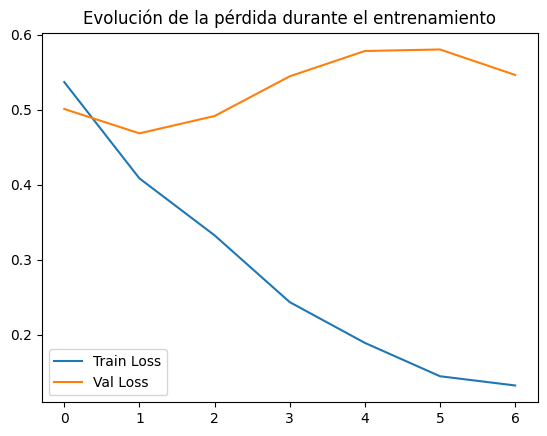

In [28]:
# PÉRDIDA DURANTE EL ENTRENAMIENTO
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.show()


La pérdida de entrenamiento disminuye de forma constante, lo que indica que el modelo aprende patrones relevantes. La pérdida de validación mejora en las primeras iteraciones y posteriormente aumenta, señalando el inicio del sobreajuste. El mecanismo de early stopping detuvo el entrenamiento en el momento adecuado, seleccionando el modelo con mejor capacidad de generalización

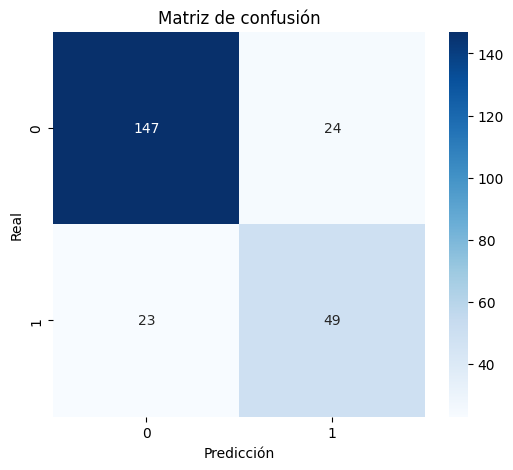

In [33]:
# MATRIZ DE CONFUSIÓN VISUAL

#Recalcular etiquetas y predicciones
all_labels = []
all_preds = []

with torch.no_grad():
    for images, num_feats, cat_feats, labels in test_loader:
        images = images.to(device)
        num_feats = num_feats.to(device)
        cat_feats = cat_feats.to(device)

        outputs = model(images, num_feats, cat_feats)
        preds = (outputs.cpu().numpy() > 0.5).astype(int)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds)

# Matriz de confusión visual
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()


La matriz de confusión muestra que el modelo clasifica correctamente la mayoría de los POIs, con 147 verdaderos negativos y 49 verdaderos positivos. Los errores se distribuyen en 24 falsos positivos y 23 falsos negativos, lo que indica un comportamiento equilibrado.
El modelo es especialmente preciso identificando POIs de bajo engagement, mientras que la clase de alto engagement resulta más difícil

Aunque el modelo obtiene buenos resultados, existen varias mejoras posibles: aumentar el dataset, aplicar data augmentation más agresivo, probar arquitecturas CNN más potentes, ajustar el umbral de clasificación, rebalancear las clases, experimentar con nuevas funciones de pérdida y optimizar hiperparámetros. Estas mejoras podrían reducir los falsos positivos y falsos negativos observados.

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


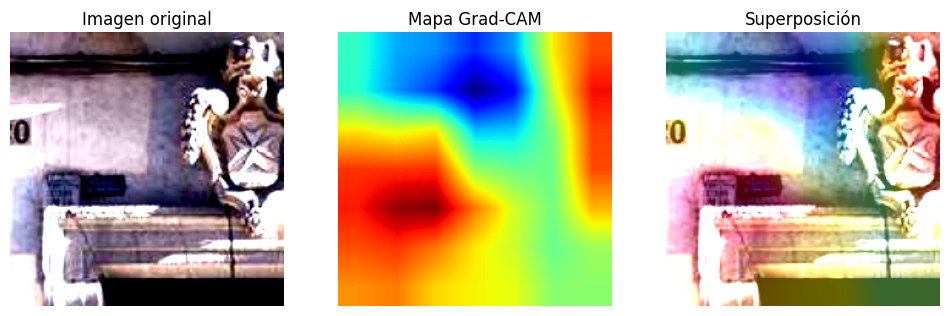

In [27]:
# GRAD-CAM PARA LA RAMA VISUAL

import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Cogemos la última capa de ResNet18
target_layer = model.cnn.layer4[-1]

# Variables para almacenar
activations = None
gradients = None

def save_activation(module, input, output):
    global activations
    activations = output.detach()

def save_gradient(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0].detach()

# Registro de hooks
target_layer.register_forward_hook(save_activation)
target_layer.register_backward_hook(save_gradient)

# Seleccion de  una imagen del test_loader
images, num_feats, cat_feats, labels = next(iter(test_loader))

image = images[0].unsqueeze(0).to(device)
num_f = num_feats[0].unsqueeze(0).to(device)
cat_f = cat_feats[0].unsqueeze(0).to(device)

# Forward
model.eval()
output = model(image, num_f, cat_f)

# Backward sobre la clase positiva (engagement alto)
model.zero_grad()
output.backward()

# Grad-CAM: gradientes globalmente promediados
weights = gradients.mean(dim=(2, 3), keepdim=True)

# Mapa de calor
cam = (weights * activations).sum(dim=1).squeeze()
cam = F.relu(cam)
cam = cam.cpu().numpy()

# Normalizacion
cam = cam - cam.min()
cam = cam / cam.max()

# Conversión de la imagen original para visualizarla
img_np = images[0].permute(1, 2, 0).cpu().numpy()
img_np = (img_np * 0.5) + 0.5
img_np = np.clip(img_np, 0, 1)

# Redimensión del mapa de calor al tamaño de la imagen
cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))

# Superposición
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
superimposed = 0.4 * heatmap / 255 + img_np

# Resultados
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Imagen original")
plt.imshow(img_np)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Mapa Grad-CAM")
plt.imshow(cam_resized, cmap="jet")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Superposición")
plt.imshow(superimposed)
plt.axis("off")

plt.show()


Para interpretar la parte visual del modelo utilicé Grad CAM, una técnica que permite visualizar qué regiones de la imagen han sido más importantes para la predicción.
Registré las activaciones y gradientes de la última capa convolucional de la ResNet18 y generé un mapa de calor que muestra las zonas más relevantes para la clasificación.